# Fashion MNIST -  Input och preprocessing

In [2]:
# Importera bibliotek
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import fashion_mnist

import cv2

tf.keras.utils.set_random_seed(42)

## Förstå datan

In [12]:
# Ladda in Fashion MNIST dataset
# https://keras.io/api/datasets/fashion_mnist/
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

In [13]:
# Undersöka vilken typ av data Fashion MNIST datasetet innehåller

# Kontrollera datatyp
print("Datatyp för träningsdata:", type(X_train))
print("Datatyp för träningslabels:", type(y_train))

# Kontrollera elementtypen
print("\nElementtyp för träningsdata:", X_train.dtype)
print("Elementtyp för träningslabels:", y_train.dtype)

# Visa shape för den första datapunkten
print("\nShape av den första datapunkten:")
print(X_train[0].shape)

# Visa den första datapunkten
print("\nFörsta datapunkten i x_train:")
print(X_train[0])

# Kontrollera min/max värdena
print("\nMinsta värde i träningsdata:", X_train.min())
print("Största värde i träningsdata:", X_train.max())

Datatyp för träningsdata: <class 'numpy.ndarray'>
Datatyp för träningslabels: <class 'numpy.ndarray'>

Elementtyp för träningsdata: uint8
Elementtyp för träningslabels: uint8

Shape av den första datapunkten:
(28, 28)

Första datapunkten i x_train:
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0

In [14]:
# Storlek och struktur på träningsdata och testdata

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


### Undersökning av datasetet

Datasetet innehåller 'numpy.ndarray' (NumPy arrayer) med numeriska värden (uint8).  

Datatypen *uint8* visar att datan består av heltal mellan 0 och 255.  

När vi undersöker den första datapunkten i träningsdatan (x_train) ser vi att den representeras som en matris (med numeriska värden) med storleken 28x28. 

Det minsta värdet är 0 och det största är 255.    

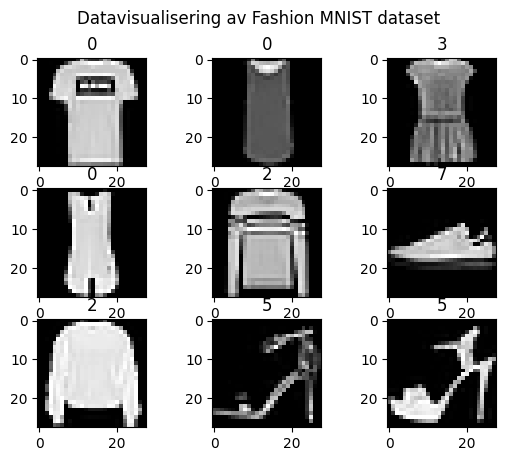

In [15]:
# Datavisualisering av Fashion MNIST datasetet

plt.suptitle("Datavisualisering av Fashion MNIST dataset")

for i in range(1, 10):
    plt.subplot(3, 3, i)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(y_train[i])

plt.show()

### Visualisering av datasetet

Ovanför visas 9 datapunkter från Fashion MNIST datasetet.

Genom visualiseringen kan vi se att datan representerar grayscale-bilder med storleken 28x28 pixlar.

### Datasetets struktur

Fashion MNIST datasetet innehåller:

- 60 000 träningsbilder
- 10 000 testbilder

Varje bild har storleken 28x28 pixlar och är i grayscale-format.

In [9]:
# Visa vilka klasser som finns i datasetet

print("Unika klasser:", np.unique(y_train), "\n")

# Kontrollera klassfördelning

unique, counts = np.unique(y_train, return_counts=True)

for label, count in zip(unique, counts):
    print(f"Klass {label}: {count} bilder")

Unika klasser: [0 1 2 3 4 5 6 7 8 9] 

Klass 0: 6000 bilder
Klass 1: 6000 bilder
Klass 2: 6000 bilder
Klass 3: 6000 bilder
Klass 4: 6000 bilder
Klass 5: 6000 bilder
Klass 6: 6000 bilder
Klass 7: 6000 bilder
Klass 8: 6000 bilder
Klass 9: 6000 bilder


### Klassfördelning

Datasetet innehåller 10 olika klasser representerade av siffrorna 0–9.

Varje klass motsvarar en viss typ av klädesplagg.   

Alla klasser innehåller 6000 bilder, vilket betyder att datasetet är balanserat och inte innehåller några tydliga obalanser mellan klasserna.

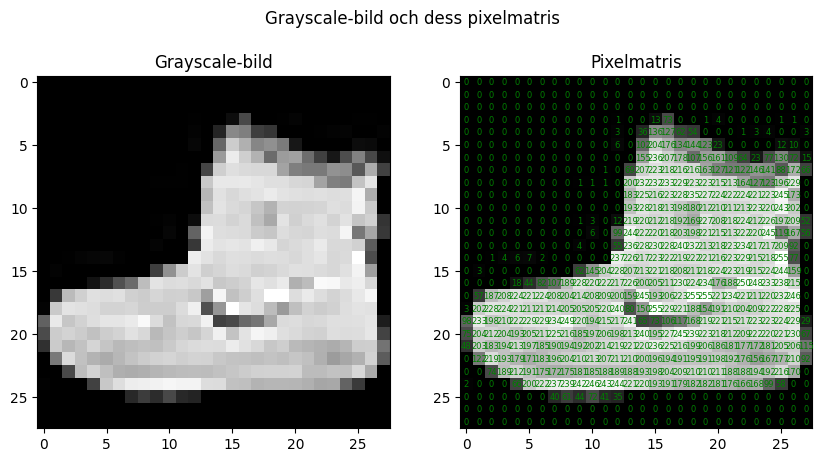

In [16]:
# Visa en grayscale-bild och dess pixelmatris
plt.figure(figsize=(10,5))
plt.suptitle("Grayscale-bild och dess pixelmatris")

# Visa grayscale-bilde
plt.subplot(1,2,1)
plt.imshow(X_train[0], cmap="gray")
plt.title("Grayscale-bild")

# Visa pixelvärden som matris
plt.subplot(1,2,2)
plt.imshow(X_train[0], cmap="gray")
plt.title("Pixelmatris")

# i = row, j = column; 28 rows, 28 columns
for i in range(28):
    for j in range(28):
        plt.text(j, i, X_train[0][i, j],
                 ha="center", va="center", fontsize=6, color="green")

plt.show()

Visualiseringen hjälper oss att förstå hur bilddata representeras som numeriska matriser i deep learning.

### Sammanfattning av datasetet
#### Input-data för deep learning

Fashion MNIST innehåller grayscale-bilder med storleken 28x28 pixlar.  

*x_train* och *x_test* innehåller bilderna, medan *y_train* och *y_test* innehåller klasser för varje bild.

Bilderna representeras som numeriska matriser där varje värde motsvarar intensiteten hos en pixel i bilden, där pixelvärden varierar från 0 (svart) till 255 (vitt).  

Eftersom bilderna är i grayscale-format representeras de i två dimensioner (28x28).  

Färgbilder skulle istället innehålla tre kanaler (RGB) och representeras som tredimensionella matriser.   

## Dela upp data i training och validation

Vi vill dela upp träningsdatan i träning och validation. Vi använder en test storlek på 10% och vi använder stratify så klassfördelningen blir ungefär lika i träning och validation.

In [17]:
X_train_base, X_val_base, y_train_base, y_val_base = train_test_split(
    X_train,
    y_train,
    test_size=0.10,
    random_state=42,
    stratify=y_train
)

print("X_train", X_train_base.shape)
print("X_val", X_val_base.shape)
print("X_test", X_test.shape)

X_train (54000, 28, 28)
X_val (6000, 28, 28)
X_test (10000, 28, 28)


In [18]:
# Lägga till en kanaldimension

X_train_base = X_train_base[..., np.newaxis]
X_val_base = X_val_base[..., np.newaxis]
X_test_base = X_test[..., np.newaxis]

print("X_train shape efter kanal dimension", X_train_base.shape)
print("X_val shape efter kanal dimension", X_val_base.shape)
print("X_test shape efter kanal dimension", X_test_base.shape)

X_train shape efter kanal dimension (54000, 28, 28, 1)
X_val shape efter kanal dimension (6000, 28, 28, 1)
X_test shape efter kanal dimension (10000, 28, 28, 1)


Varje bild i datasetet har storleken 28 × 28 pixlar. En Convolutional Neural Network (CNN) förväntar sig vanligtvis att inputdata har formen (höjd, bredd, kanaler).

För färgbilder används oftast tre kanaler (röd, grön och blå). Eftersom Fashion MNIST består av gråskalebilder har varje bild endast en kanal.

Därför lägger vi till en extra dimension i datan så att varje bild får formen 28 × 28 × 1. Detta gör att datan får rätt format för CNN-modellen. 

## Bygg en modell (CNN)

In [21]:
# Vi skapar en enkel CNN-modell för bildklassificering.

def create_model():

    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(32, (3,3),
                      activation='relu',
                      padding='same'),

        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3),
                      activation='relu',
                      padding='same'),

        layers.MaxPooling2D((2,2)),

        layers.Flatten(),

        layers.Dense(64, activation='relu'),

        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

## Träna modellen

- träna modellen på träningsdata
- använda validation
- observera hur modellen utvecklas över tid

In [22]:
# träna baseline-modellen
model_base = create_model()

history_base = model_base.fit(
    X_train_base,
    y_train_base,
    validation_data=(X_val_base, y_val_base),
    epochs=5,
    batch_size=64
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.8403 - loss: 0.6286 - val_accuracy: 0.8677 - val_loss: 0.3502
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.8960 - loss: 0.2900 - val_accuracy: 0.8847 - val_loss: 0.3072
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9105 - loss: 0.2473 - val_accuracy: 0.8808 - val_loss: 0.3159
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9185 - loss: 0.2208 - val_accuracy: 0.8878 - val_loss: 0.3318
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9261 - loss: 0.1990 - val_accuracy: 0.8897 - val_loss: 0.3213


In [23]:
model_base.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 660,704 (2.52 MB)

 Trainable params: 220,234 (860.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 440,470 (1.68 MB)

Vi kompilerar vår baseline-modell med optimeraren Adam och en learning rate på 0.001. Adam används eftersom den är effektiv för de flesta neurala nätverk och anpassar inlärningshastigheten under träning.

Vi använder Sparse Categorical Crossentropy som loss-funktion eftersom det är ett multiklassklassificeringsproblem där labels är heltal mellan 0 och 9.

Som utvärderingsmetrik använder vi accuracy, eftersom detta är ett relativt balanserat dataset med jämnt fördelade klasser, vilket gör accuracy till ett lämpligt mått för att bedöma modellens prestanda.

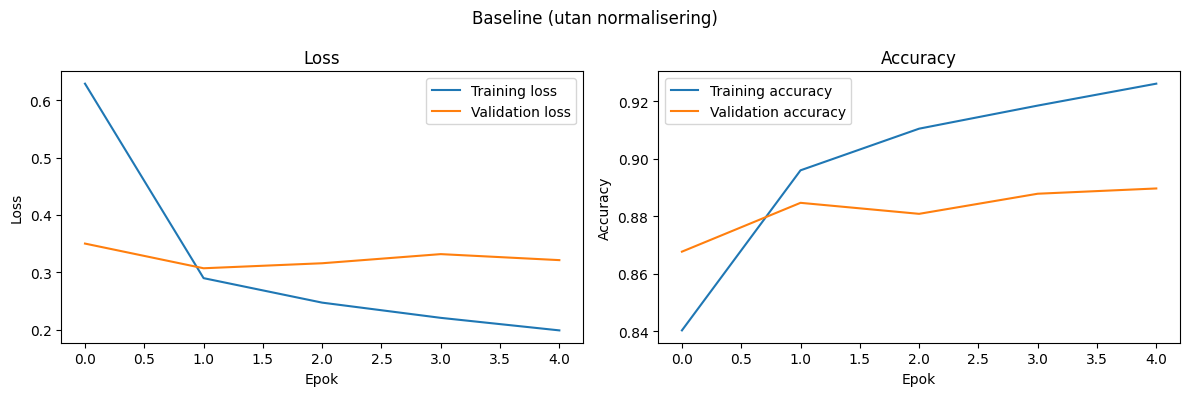

In [24]:
# Träningskurvor

def plot_history(history, title="Träningskurvor"):
    history_df = pd.DataFrame(history.history)

    plt.figure(figsize=(12,4))

    #Loss
    plt.subplot(1,2,1)
    plt.plot(history_df["loss"], label="Training loss")
    plt.plot(history_df["val_loss"], label="Validation loss")
    plt.xlabel("Epok")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()

    #Accuracy
    plt.subplot(1,2,2)
    plt.plot(history_df["accuracy"], label="Training accuracy")
    plt.plot(history_df["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epok")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_history(history_base, title="Baseline (utan normalisering)")


Modellen lär sig snabbt under de första epokerna. Training loss minskar samtidigt som training accuracy ökar, vilket visar att modellen anpassar sig till träningsdatan.

Även validation loss minskar, vilket tyder på att modellen förbättrar sin generaliseringsförmåga och presterar bättre på ny data.

In [25]:
# Utvärdera på testdata

test_loss_base, test_accuracy_base = model_base.evaluate(X_test_base, y_test, verbose=0)

print(f"Test loss: {test_loss_base:.4f}")
print(f"Test accuracy: {test_accuracy_base:.4f}")

Test loss: 0.3617
Test accuracy: 0.8802


Testresultatet är något sämre än validation-resultatet. Detta är inte ovanligt och kan bero på att validation-setet kommer från samma ursprungliga träningsdata, medan test-setet består av helt osedda bilder.

Validation-resultatet kan därför vara något mer optimistiskt, eftersom modellen indirekt har använts för att övervaka och justera träningen utifrån denna data.

Skillnaden kan även bero på naturlig variation i datan, där testsetet kan innehålla exempel som är svårare att klassificera än validation-setet. Trots detta tyder resultaten på att modellen generaliserar relativt bra.

## Preprocessing-metoder

### Normalisering

Vi normaliserar våra pixelvärden. Vi delar alla pixelvärden med 255 så att dem hamnar mellan 0 och 1 istället.

In [26]:
# Normalisering
X_train_norm = X_train_base.astype("float32") / 255.0
X_val_norm = X_val_base.astype("float32") / 255.0
X_test_norm = X_test_base.astype("float32") / 255.0

# Kontrollera minsta och största värden efter normalisering
print("Minsta värde efter normalisering:", X_train_norm.min())
print("Största värde efter normalisering:", X_train_norm.max())

Minsta värde efter normalisering: 0.0
Största värde efter normalisering: 1.0


In [27]:
model_norm = create_model()

history_norm = model_norm.fit(
    X_train_norm,
    y_train_base,
    validation_data=(X_val_norm, y_val_base),
    epochs=5,
    batch_size=64
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 24ms/step - accuracy: 0.8364 - loss: 0.4529 - val_accuracy: 0.8775 - val_loss: 0.3256
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.8931 - loss: 0.2957 - val_accuracy: 0.8972 - val_loss: 0.2838
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.9084 - loss: 0.2523 - val_accuracy: 0.9032 - val_loss: 0.2666
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.9191 - loss: 0.2221 - val_accuracy: 0.9075 - val_loss: 0.2526
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9284 - loss: 0.1961 - val_accuracy: 0.9128 - val_loss: 0.2421


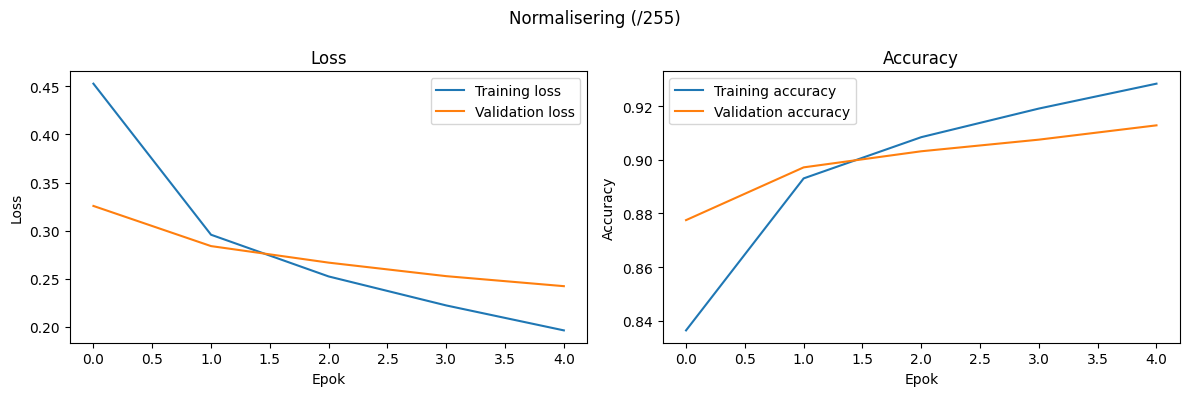

In [28]:
plot_history(history_norm, title="Normalisering (/255)")

Skillnaden mellan training accuracy och validation accuracy är relativt liten, vilket tyder på att modellen generaliserar ganska bra.

In [29]:
# Utvärdera på testdata

test_loss_norm, test_accuracy_norm = model_norm.evaluate(
    X_test_norm,
    y_test,
    verbose=0
)

print(f"Test loss (norm): {test_loss_norm:.4f}")
print(f"Test accuracy (norm): {test_accuracy_norm:.4f}")

Test loss (norm): 0.2768
Test accuracy (norm): 0.9009


### Standardisering

In [30]:
# Modell med standardisering
mean = X_train_base.mean()
std = X_train_base.std()

X_train_std = (X_train_base - mean) / std
X_val_std = (X_val_base - mean) / std
X_test_std = (X_test_base - mean) / std

In [31]:
model_std = create_model()

history_std = model_std.fit(
    X_train_std,
    y_train_base,
    validation_data=(X_val_std, y_val_base),
    epochs=5,
    batch_size=64
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.8440 - loss: 0.4334 - val_accuracy: 0.8778 - val_loss: 0.3266
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.8957 - loss: 0.2848 - val_accuracy: 0.9025 - val_loss: 0.2701
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9128 - loss: 0.2391 - val_accuracy: 0.9077 - val_loss: 0.2527
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.9246 - loss: 0.2063 - val_accuracy: 0.9132 - val_loss: 0.2424
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.9346 - loss: 0.1794 - val_accuracy: 0.9188 - val_loss: 0.2355


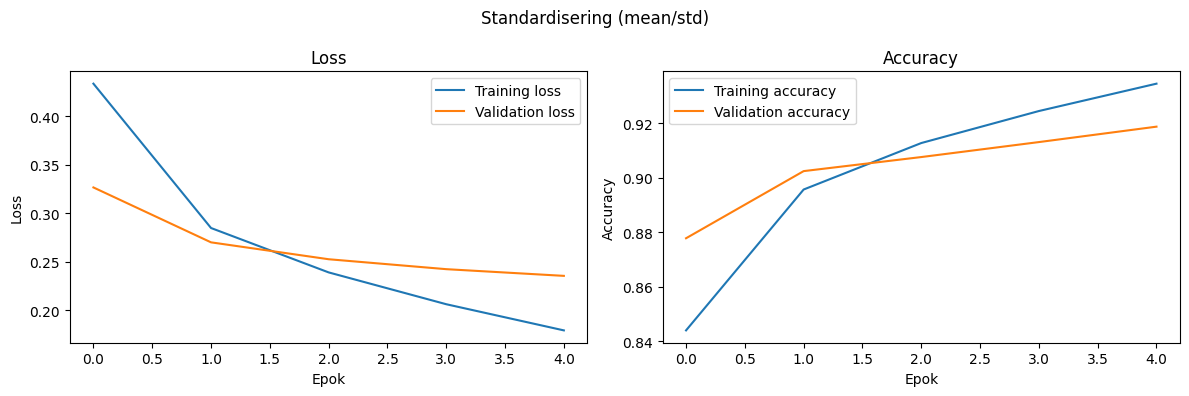

In [32]:
plot_history(history_std, title="Standardisering (mean/std)")

Modellen lär sig snabbt under de första epokerna. Training loss minskar samtidigt som training accuracy ökar, vilket visar att modellen anpassar sig till träningsdatan.

Även validation loss minskar i början, vilket tyder på att modellen förbättrar sin generaliseringsförmåga och presterar bättre på ny data.

Efter några epoker börjar dock validation loss plana ut, medan training loss fortsätter att minska. Detta kan vara ett tidigt tecken på överanpassning (overfitting), där modellen lär sig träningsdatan för väl.

Skillnaden mellan training accuracy och validation accuracy är dock relativt liten, vilket tyder på att modellen fortfarande generaliserar ganska bra.

In [33]:
# Utvärdera på testdata

test_loss_std, test_accuracy_std = model_std.evaluate(
    X_test_std,
    y_test,
    verbose=0
)

print(f"Test loss (std): {test_loss_std:.4f}")
print(f"Test accuracy (std): {test_accuracy_std:.4f}")

Test loss (std): 0.2777
Test accuracy (std): 0.9024


#### Jämförelse mellan baseline, normalisering och standardisering

In [34]:
results = pd.DataFrame({
    "Experiment": ["Baseline", "Normalisering", "Standardisering"],
    "Test Accuracy": [test_accuracy_base, test_accuracy_norm, test_accuracy_std],
    "Test Loss": [test_loss_base, test_loss_norm, test_loss_std]
})

results

,Experiment,Test Accuracy,Test Loss
0,Baseline,0.8802,0.361749
1,Normalisering,0.9009,0.276836
2,Standardisering,0.9024,0.277696


Normalisering gav bäst resultat med högst accuracy och lägst loss. Standardisering fungerade också bra men förbättringen var något mindre.

### Låg upplösning (16x16)

In [35]:
resolution = 16

X_train_low = np.array([cv2.resize(img.squeeze(), (resolution, resolution), interpolation=cv2.INTER_LINEAR) for img in X_train_base])
X_val_low = np.array([cv2.resize(img.squeeze(), (resolution, resolution), interpolation=cv2.INTER_LINEAR) for img in X_val_base])
X_test_low = np.array([cv2.resize(img.squeeze(), (resolution, resolution), interpolation=cv2.INTER_LINEAR) for img in X_test_base])

# Add channel dimension
X_train_low = X_train_low[..., np.newaxis]
X_val_low = X_val_low[..., np.newaxis]
X_test_low = X_test_low[..., np.newaxis]

print(f"Resized to {resolution}x{resolution}")
print(f"X_train shape: {X_train_low.shape}")
print(f"X_val shape: {X_val_low.shape}")
print(f"X_test shape: {X_test_low.shape}")

Resized to 16x16
X_train shape: (54000, 16, 16, 1)
X_val shape: (6000, 16, 16, 1)
X_test shape: (10000, 16, 16, 1)


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8157 - loss: 0.6418 - val_accuracy: 0.8578 - val_loss: 0.3861
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8756 - loss: 0.3426 - val_accuracy: 0.8728 - val_loss: 0.3491
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8907 - loss: 0.2992 - val_accuracy: 0.8790 - val_loss: 0.3278
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8995 - loss: 0.2732 - val_accuracy: 0.8818 - val_loss: 0.3235
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9055 - loss: 0.2551 - val_accuracy: 0.8602 - val_loss: 0.3827


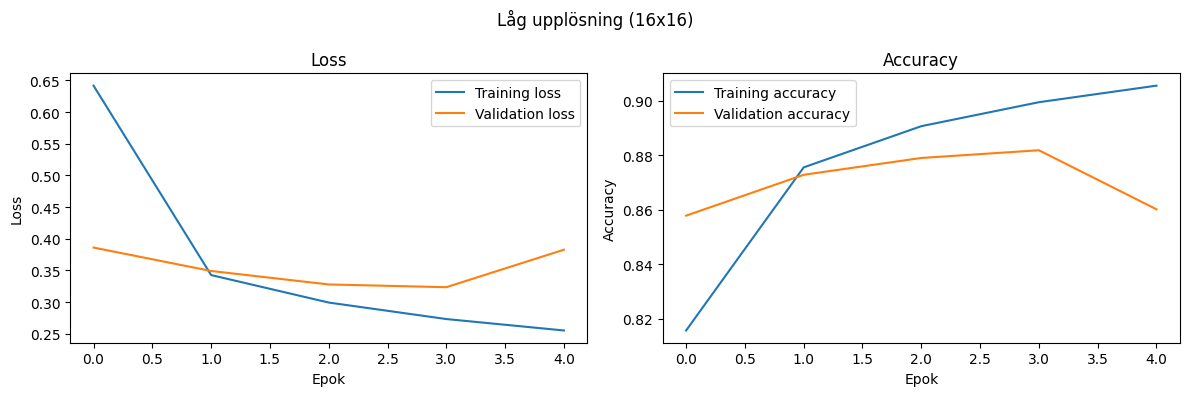

In [36]:
model_low = keras.Sequential([
    layers.Input(shape=(16, 16, 1)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_low.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_low = model_low.fit(
    X_train_low,
    y_train_base,
    validation_data=(X_val_low, y_val_base),
    epochs=5,
    batch_size=64
)

plot_history(history_low, title="Låg upplösning (16x16)")

In [37]:
test_loss_low, test_accuracy_low = model_low.evaluate(
    X_test_low,
    y_test,
    verbose=0
)

print(f"Test loss (låg upplösning): {test_loss_low:.4f}")
print(f"Test accuracy (låg upplösning): {test_accuracy_low:.4f}")

Test loss (låg upplösning): 0.4184
Test accuracy (låg upplösning): 0.8548


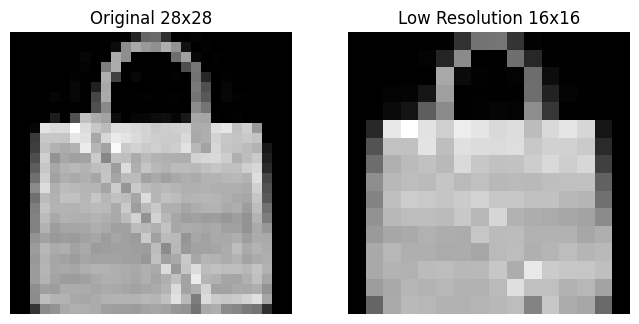

In [38]:
# Jämförelse mellan originalbild och låg upplösning

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(X_train_base[0].squeeze(), cmap="gray")
plt.title("Original 28x28")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(X_train_low[0].squeeze(), cmap="gray")
plt.title("Low Resolution 16x16")
plt.axis("off")

plt.savefig("../images/low_resolution_example.png", bbox_inches='tight')
plt.show()

Lägre upplösning gav sämre resultat eftersom viktiga bilddetaljer försvann.

### JPEG-komprimering

Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.6068 - loss: 1.0745 - val_accuracy: 0.7380 - val_loss: 0.7475
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7864 - loss: 0.6001 - val_accuracy: 0.7840 - val_loss: 0.5656
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8256 - loss: 0.5001 - val_accuracy: 0.8190 - val_loss: 0.4945
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8476 - loss: 0.4453 - val_accuracy: 0.8370 - val_loss: 0.4473
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8654 - loss: 0.4008 - val_accuracy: 0.8450 - val_loss: 0.4117


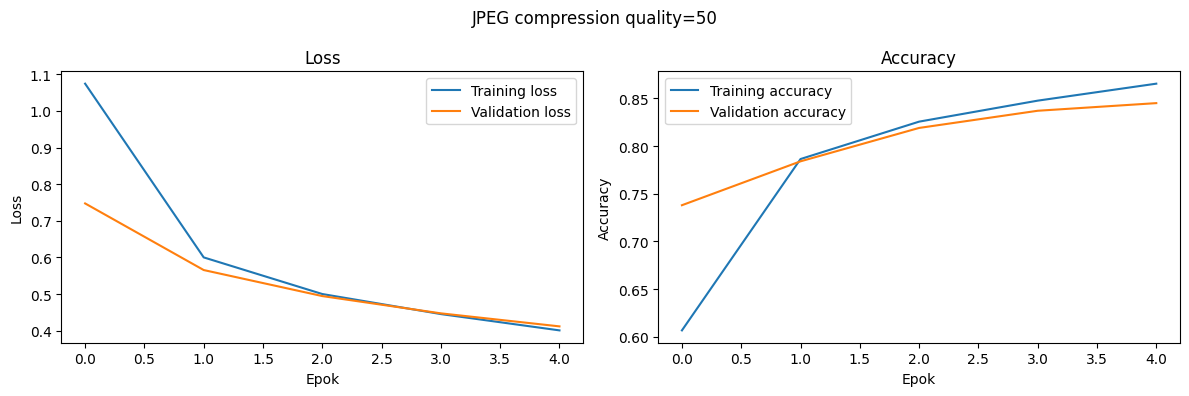

Test loss (compressed): 0.4565
Test accuracy (compressed): 0.8480


In [39]:
# Compress with JPEG quality 50 in-memory and train the same model

def jpeg_compress(images, quality=50):
    compressed = []
    for img in images:
        success, encoded = cv2.imencode('.jpg', img, [cv2.IMWRITE_JPEG_QUALITY, quality])
        compressed_img = cv2.imdecode(encoded, cv2.IMREAD_GRAYSCALE)
        compressed.append(compressed_img)
    return np.array(compressed, dtype='float32')[..., np.newaxis] / 255.0

n_samples = 5000
X_train_comp = jpeg_compress(X_train_base[:n_samples].squeeze())
X_val_comp = jpeg_compress(X_val_base[:1000].squeeze())
X_test_comp = jpeg_compress(X_test_base[:1000].squeeze())

model_comp = create_model()

history_comp = model_comp.fit(
    X_train_comp,
    y_train_base[:n_samples],
    validation_data=(X_val_comp, y_val_base[:1000]),
    epochs=5,
    batch_size=64
)

plot_history(history_comp, title='JPEG compression quality=50')

loss_comp, acc_comp = model_comp.evaluate(X_test_comp, y_test[:1000], verbose=0)
print(f'Test loss (compressed): {loss_comp:.4f}')
print(f'Test accuracy (compressed): {acc_comp:.4f}')

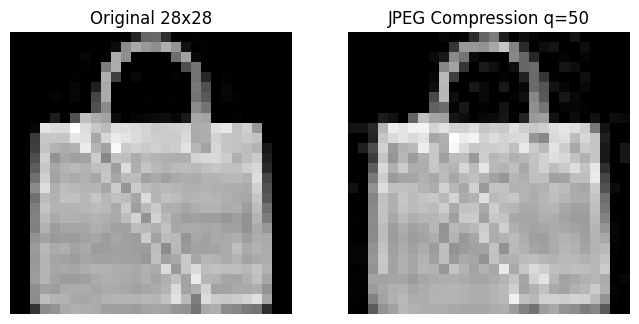

In [40]:
# Jämförelse mellan originalbild och JPEG-kompression

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(X_train_base[0].squeeze(), cmap="gray")
plt.title("Original 28x28")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(X_train_comp[0].squeeze(), cmap="gray")
plt.title("JPEG Compression q=50")
plt.axis("off")

plt.savefig("../images/compression_example.png", bbox_inches='tight')

plt.show()

JPEG-kompression försämrade bildkvaliteten och tog bort viktiga detaljer i bilderna. Det gjorde att modellens accuracy blev lägre jämfört med baseline-modellen.

###  Data augmentation

In [41]:
weak_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08)
])

strong_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.20),
    layers.RandomTranslation(0.15, 0.15),
    layers.RandomZoom(0.20),
    layers.RandomContrast(0.25)
])


def build_dataset(x, y, augmentation=None, batch_size=64):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if augmentation is not None:
        ds = ds.map(lambda x, y: (augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.shuffle(2000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

n_samples = 5000
train_ds_weak = build_dataset(X_train_norm[:n_samples], y_train_base[:n_samples], weak_aug)
train_ds_strong = build_dataset(X_train_norm[:n_samples], y_train_base[:n_samples], strong_aug)
val_ds = build_dataset(X_val_norm[:1000], y_val_base[:1000])
test_ds = build_dataset(X_test_norm[:1000], y_test[:1000])

model_weak = create_model()
history_weak = model_weak.fit(train_ds_weak, validation_data=val_ds, epochs=5)
loss_weak, acc_weak = model_weak.evaluate(test_ds, verbose=0)

model_strong = create_model()
history_strong = model_strong.fit(train_ds_strong, validation_data=val_ds, epochs=5)
loss_strong, acc_strong = model_strong.evaluate(test_ds, verbose=0)

print(f"Weak augmentation test accuracy: {acc_weak:.4f}")
print(f"Strong augmentation test accuracy: {acc_strong:.4f}")

pd.DataFrame({
    "Experiment": ["Weak augmentation", "Strong augmentation"],
    "Test Accuracy": [acc_weak, acc_strong],
    "Test Loss": [loss_weak, loss_strong]
})

Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.5240 - loss: 1.3098 - val_accuracy: 0.7080 - val_loss: 0.7990
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7074 - loss: 0.8026 - val_accuracy: 0.7500 - val_loss: 0.6951
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7374 - loss: 0.7091 - val_accuracy: 0.7700 - val_loss: 0.6097
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7598 - loss: 0.6598 - val_accuracy: 0.7580 - val_loss: 0.6038
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7804 - loss: 0.6049 - val_accuracy: 0.7370 - val_loss: 0.6593
Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.3078 - loss: 1.9036 - val_accuracy: 0.5940 - val_loss: 1.2611
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.4544 - loss: 1.5393 - val_accuracy: 0.6330 - val_loss: 1.0532
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.5112 - loss: 1.3797 - val_accuracy: 0.5070 - val_loss:

,Experiment,Test Accuracy,Test Loss
0,Weak augmentation,0.696,0.745828
1,Strong augmentation,0.573,1.162997


Weak augmentation gav högre accuracy och lägre loss än strong augmentation.

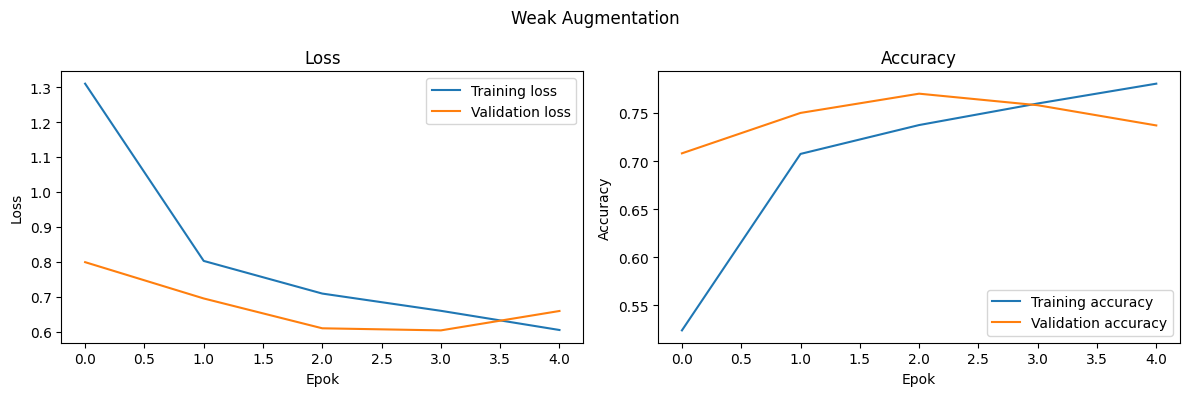

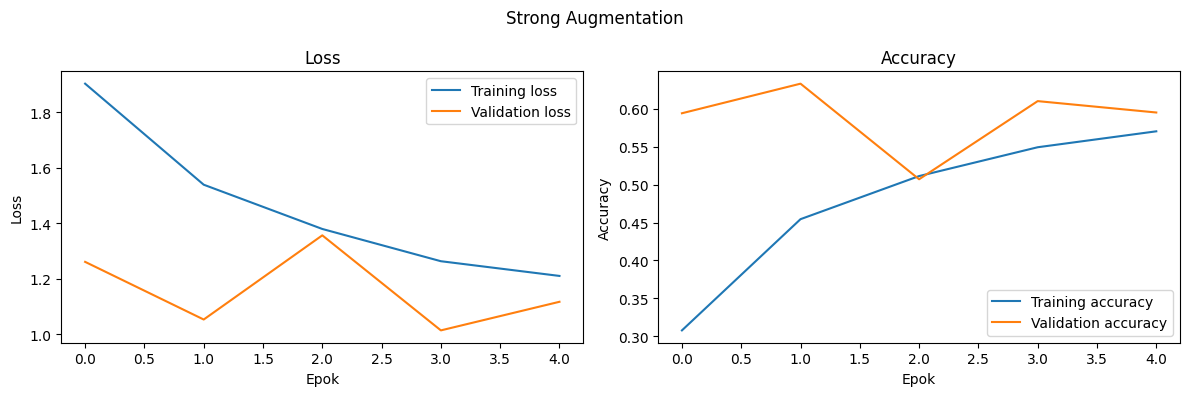

In [42]:
plot_history(history_weak, title="Weak Augmentation")
plot_history(history_strong, title="Strong Augmentation")

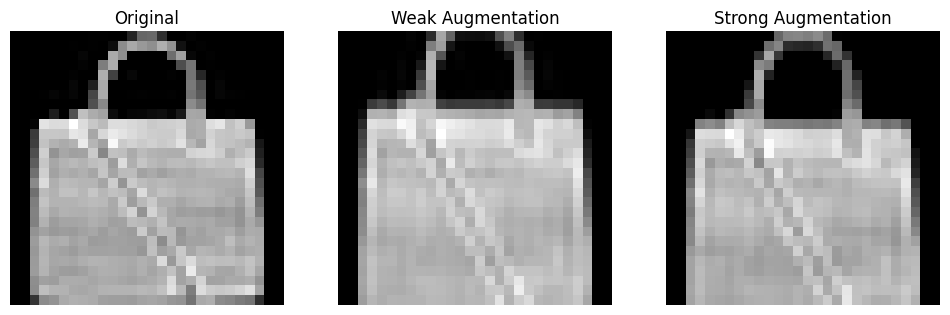

In [43]:
# Visa skillnaden mellan originalbild, weak augmentation och strong augmentation

original = X_train_norm[0]

weak_image = weak_aug(tf.expand_dims(original, 0), training=True)
strong_image = strong_aug(tf.expand_dims(original, 0), training=True)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(original.squeeze(), cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(weak_image[0].numpy().squeeze(), cmap="gray")
plt.title("Weak Augmentation")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(strong_image[0].numpy().squeeze(), cmap="gray")
plt.title("Strong Augmentation")
plt.axis("off")

plt.savefig("../images/augmentation_example.png", bbox_inches='tight')

plt.show()

Weak augmentation skapade små förändringar i bilderna men gav ingen tydlig förbättring av accuracy. Strong augmentation gav däremot mycket sämre resultat eftersom bilderna förändrades för mycket och blev svårare för modellen att känna igen.

### MixUp

In [ ]:
# Simple MixUp: blend pairs of images and labels
n_samples = 5000
x = X_train_norm[:n_samples]
y = y_train_base[:n_samples]

idx = np.random.permutation(n_samples)
lam = np.random.beta(0.2, 0.2, size=n_samples)

x_mix = x * lam[:, None, None, None] + x[idx] * (1 - lam[:, None, None, None])
y_mix = tf.one_hot(y, 10) * lam[:, None] + tf.one_hot(y[idx], 10) * (1 - lam[:, None])

model_mix = create_model()
model_mix.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_mix = model_mix.fit(x_mix, y_mix, validation_data=(X_val_norm[:1000], tf.one_hot(y_val_base[:1000], 10)), epochs=5, batch_size=64)

loss_mix, acc_mix = model_mix.evaluate(X_test_norm[:1000], tf.one_hot(y_test[:1000], 10), verbose=0)
print(f'MixUp test accuracy: {acc_mix:.4f}')

pd.DataFrame({"Experiment": ["MixUp"], "Test Accuracy": [acc_mix], "Test Loss": [loss_mix]})

Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.6150 - loss: 1.2276 - val_accuracy: 0.7710 - val_loss: 0.6557
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7744 - loss: 0.8532 - val_accuracy: 0.7990 - val_loss: 0.5523
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8170 - loss: 0.7702 - val_accuracy: 0.8250 - val_loss: 0.4970
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.8364 - loss: 0.7214 - val_accuracy: 0.8410 - val_loss: 0.4609
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8518 - loss: 0.6820 - val_accuracy: 0.8530 - val_loss: 0.4354
MixUp test accuracy: 0.8410


,Experiment,Test Accuracy,Test Loss
0,MixUp,0.841,0.47932


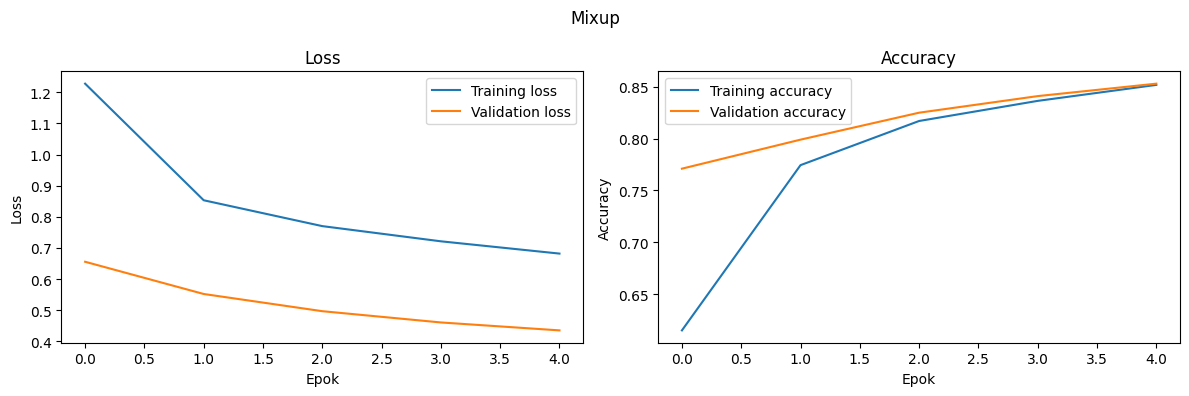

In [45]:
plot_history(history_mix, title='Mixup')

MixUp gav lägre accuracy och högre loss än normalisering, men resultatet var fortfarande bättre än strong augmentation.

### Center crop

In [47]:
# Center crop experiment: crop 28×28 images to 24×24 and compare performance

def create_model_input(shape):
    model = keras.Sequential([
        layers.Input(shape=shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


def center_crop_images(images, crop_size=24):
    start = (images.shape[1] - crop_size) // 2
    end = start + crop_size
    return images[:, start:end, start:end, :]

X_train_crop = center_crop_images(X_train_base, crop_size=24)
X_val_crop = center_crop_images(X_val_base, crop_size=24)
X_test_crop = center_crop_images(X_test_base, crop_size=24)

X_train_crop = X_train_crop.astype('float32') / 255.0
X_val_crop = X_val_crop.astype('float32') / 255.0
X_test_crop = X_test_crop.astype('float32') / 255.0

print('X_train_crop shape:', X_train_crop.shape)
print('X_val_crop shape:', X_val_crop.shape)
print('X_test_crop shape:', X_test_crop.shape)

model_crop = create_model_input((24, 24, 1))
history_crop = model_crop.fit(
    X_train_crop,
    y_train_base,
    validation_data=(X_val_crop, y_val_base),
    epochs=5,
    batch_size=64,
    verbose=0
)

loss_crop, acc_crop = model_crop.evaluate(X_test_crop, y_test, verbose=0)
print(f'Center crop test accuracy: {acc_crop:.4f}')
print(f'Center crop test loss: {loss_crop:.4f}')


X_train_crop shape: (54000, 24, 24, 1)
X_val_crop shape: (6000, 24, 24, 1)
X_test_crop shape: (10000, 24, 24, 1)
Center crop test accuracy: 0.8797
Center crop test loss: 0.3229


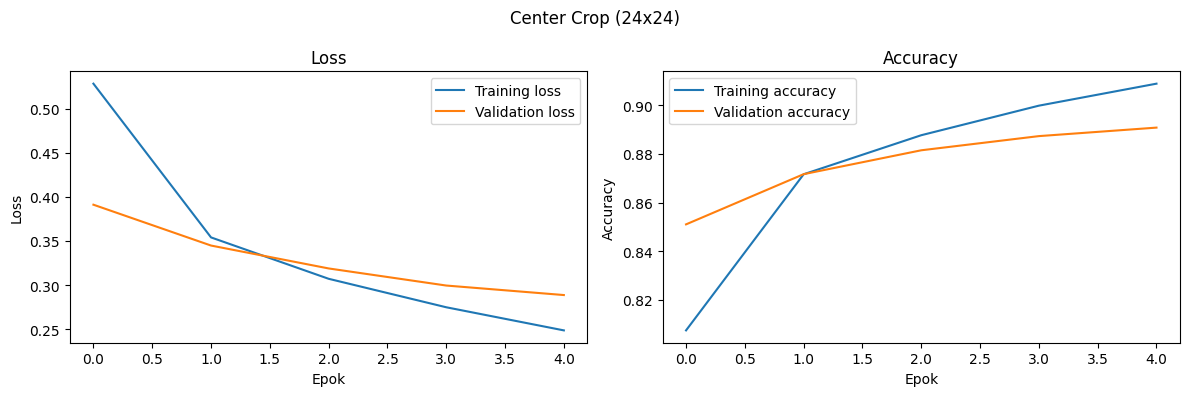

In [48]:
plot_history(history_crop, title='Center Crop (24x24)')

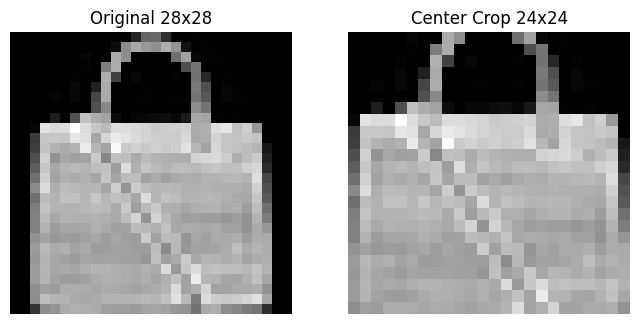

In [49]:
# Jämförelse mellan originalbild och center crop

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(X_train_base[0].squeeze(), cmap="gray")
plt.title("Original 28x28")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(X_train_crop[0].squeeze(), cmap="gray")
plt.title("Center Crop 24x24")
plt.axis("off")

plt.savefig("../images/center_crop_example.png", bbox_inches='tight')

plt.show()

Center crop tog bort delar av bildens kanter, men accuracy påverkades bara lite eftersom den viktigaste informationen fortfarande fanns kvar i mitten av bilderna.

##  Jämförelse av input-format: CNN vs Dense

Här jämför vi CNN-modeller med Dense-modeller för att undersöka hur olika input-format påverkar resultaten.

In [51]:
# Här jämför vi CNN-modeller med Dense-modeller för att undersöka hur olika input-format påverkar resultaten.
def create_dense(input_dim):
    m = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

# Flat 28x28 (använd normaliserad data)
X_train_flat = X_train_norm.reshape(len(X_train_norm), -1)
X_val_flat = X_val_norm.reshape(len(X_val_norm), -1)
X_test_flat = X_test_norm.reshape(len(X_test_norm), -1)

m_dense28 = create_dense(28*28)
m_dense28.fit(X_train_flat, y_train_base, validation_data=(X_val_flat, y_val_base), epochs=5, batch_size=64, verbose=0)
loss_dense28, acc_dense28 = m_dense28.evaluate(X_test_flat, y_test, verbose=0)

# Flat 16x16 (normalisera lågupplösning och platta)
X_train_low_norm = X_train_low.astype('float32') / 255.0
X_val_low_norm = X_val_low.astype('float32') / 255.0
X_test_low_norm = X_test_low.astype('float32') / 255.0

X_train_low_flat = X_train_low_norm.reshape(len(X_train_low_norm), -1)
X_val_low_flat = X_val_low_norm.reshape(len(X_val_low_norm), -1)
X_test_low_flat = X_test_low_norm.reshape(len(X_test_low_norm), -1)

m_dense16 = create_dense(16*16)
m_dense16.fit(X_train_low_flat, y_train_base, validation_data=(X_val_low_flat, y_val_base), epochs=5, batch_size=64, verbose=0)
loss_dense16, acc_dense16 = m_dense16.evaluate(X_test_low_flat, y_test, verbose=0)

# Sammanställ enkelt (återanvänd CNN-resultat om de finns)
rows = [
    ("CNN 28x28", globals().get('test_accuracy_base', np.nan), globals().get('test_loss_base', np.nan)),
    ("Dense 28x28 (flat)", float(acc_dense28), float(loss_dense28)),
    ("CNN 16x16", globals().get('test_accuracy_low', np.nan), globals().get('test_loss_low', np.nan)),
    ("Dense 16x16 (flat)", float(acc_dense16), float(loss_dense16)),
]

df_comp = pd.DataFrame(rows, columns=["Model", "Test Accuracy", "Test Loss"]).set_index('Model')
display(df_comp)


,Test Accuracy,Test Loss
Model,,
CNN 28x28,0.8802,0.361749
Dense 28x28 (flat),0.8629,0.373903
CNN 16x16,0.8548,0.418358
Dense 16x16 (flat),0.8628,0.377207


CNN 28x28 gav bäst resultat med högst accuracy och lägst loss.

## Jämförelse av alla experiment

Här jämför vi resultaten från alla preprocessing-metoder och modeller.

In [52]:
names = ["Baseline","Normalisering (/255)","Standardisering","Låg upplösning (16x16)","Center crop (24x24)","Compressed (JPEG q=50)","Weak augmentation","Strong augmentation","MixUp","Dense 28x28 (flat)","Dense 16x16 (flat)"]
acc_vars = ["test_accuracy_base","test_accuracy_norm","test_accuracy_std","test_accuracy_low","acc_crop","acc_comp","acc_weak","acc_strong","acc_mix","acc_dense28","acc_dense16"]
loss_vars = ["test_loss_base","test_loss_norm","test_loss_std","test_loss_low","loss_crop","loss_comp","loss_weak","loss_strong","loss_mix","loss_dense28","loss_dense16"]

df = pd.DataFrame({
    "Experiment": names,
    "Test Accuracy": [globals().get(v, np.nan) for v in acc_vars],
    "Test Loss": [globals().get(v, np.nan) for v in loss_vars],
}).set_index("Experiment")

display(df)

,Test Accuracy,Test Loss
Experiment,,
Baseline,0.8802,0.361749
Normalisering (/255),0.9009,0.276836
Standardisering,0.9024,0.277696
Låg upplösning (16x16),0.8548,0.418358
Center crop (24x24),0.8797,0.322883
Compressed (JPEG q=50),0.8480,0.456461
Weak augmentation,0.6960,0.745828
Strong augmentation,0.5730,1.162997
MixUp,0.8410,0.479320


**Slutsats — bästa preprocessing**

Enligt testresultaten ger Normalisering (/255) bäst prestanda: **Test accuracy = 0.9008**.

Center crop 24×24 ger en något lägre testaccuracy (**0.8722**) än fullstor 28×28-normalisering, vilket visar att att ta bort kantinformation försämrar modellen.


Rekommendation: använd Normalisering (/255) som standardpreprocessing och verifiera med fler seeds eller CV-folds för stabilitet.

### Förklaring av scaling

Scaling är processen att transformera data så att alla features ligger i samma intervall eller har liknande egenskaper.
Det är en form av datanormalisering som gör att modellen lär sig bättre.
Neuralnät lär sig snabbare när inputvärden är små och ligger i liknande intervall. Det minskar risken för att viktuppdateringar blir för stora eller för små. Det gör optimeringen mer stabil och kan förbättra både träning- och valideringsresultat.

- Neuralnät är känsliga för storleken på inputvärden.
- Om värden är mycket stora (0–255) kan gradienter bli instabila.
- Scaling gör träningen snabbare och mer stabil.



1. Normalisering (/255): Min-Max scaling
betyder det ofta att dela varje pixelvärde med 255, eftersom originalvärdena ligger mellan 0 och 255.
Resultatet blir att alla pixlar hamnar i intervallet 0.0 till 1.0.
Formula: x_norm = x / 255
Enkel och snabb.
Din bästa metod: Test accuracy 0.9008.

2. Standardisering (mean/std): Z-score normalization
Formula: x_std = (x - mean) / std
Resultatet har medelvärde 0 och standardavvikelse 1.
Passar bra när data har en normalfördelning.
Din prestanda: Test accuracy 0.8994 (mycket nära).

### Varför vissa metoder fungerar bättre

- Normalisering (/255) fungerar bäst för bilddata eftersom pixelvärdena hamnar i samma skala [0, 1]. Det gör att neuronernas viktuppdateringar blir stabilare och inlärningen snabbare, särskilt i ett CNN som är känsligt för stora ingångsvärden.

- Standardisering ger nästan lika bra resultat eftersom den också centrerar och skalar data, men för bilder med fasta gränser är /255 ofta tillräckligt och enklare.

- Baseline utan normalisering hamnar längre ner eftersom nätverket tvingas hantera bredare värdeintervall, vilket gör optimeringen svårare.

- Låg upplösning (16×16) förlorar detaljer och finare texturer som behövs för att skilja liknande klasser i Fashion MNIST, så modellen får mindre signal att lära från.

- JPEG-kompression introducerar artefakter och störningar i bilden, vilket gör uppgiften svårare än originaldata.

- Augmentation hjälper oftast, men om den är för stark kan den skapa exempel som avviker för mycket från verkligheten och därmed förvirra modellen. Det förklarar varför “weak augmentation” kan vara bättre än “strong augmentation” i ditt experiment.

- MixUp kan ge regularisering, men det kräver ofta rätt parametrar och tillräckligt med träning för att överträffa enkel normalisering

## Slutsatser

Vi undersökte hur preprocessing påverkar deep learning-modeller. Våra resultat visar att rätt preprocessing både förbättrar accuracy och gör träningen stabilare.​

Preprocessing påverkar modellen mycket, samma modell kan ge olika resultat beroende på input.​

Normalisering hade störst positiv effekt och minskade även overfitting.​

Bildkvalitet är viktig: När information försvann försämrades modellen.​

Mer augmentation är inte alltid bättre: För stark augmentation kan göra datan (bilderna) orealistisk.​

Vi lärde oss att preprocessing inte bara förbereder datan, det påverkar direkt hur modellen lär sig att tolka bilderna.​

Nästa steg: Testa fler kombinationer av preprocessing, till exempel normalisering + weak augmentation  samtidigt, testa fler epoker och testa andra modeller.